In [1]:
from ocpa.objects.log.importer.ocel import factory as ocel_import_factory

import Super_Variant_Hierarchy as SVH
import Super_Variant_Visualization as SVV
import Intra_Variant_Generation as IAVG
import Intra_Variant_Summarization as IAVS
import Summarization_Selection as IASS
import Inter_Variant_Generation as IEVG
import Input_Extraction_Definition as IED
import Inter_Lane_Alignment as ILA

from Evaluation.utils import print_hierarchy_costs
from . import P2P_LOG, TEST_LOG_1, TEST_LOG_2

VISUALIZE_INTERMEDIATE_RESULTS = False

In [2]:
# EVALUATION Settings
ILA.ALIGN = False
filename = TEST_LOG_2 # P2P_LOG

# Import Log
ocel = ocel_import_factory.apply(file_path=filename)

## Intra-Variant Summarization

In [3]:
### FUNCTION IED.get_unique_summarizations_from_process()
from ocpa.visualization.log.variants import factory as variants_visualization_factory

# -> Division into discrete steps already happens here, viz package part of process discovery in ocpa
# {Activity: [start index, end index], [other appearances / intersections]}
variant_layout = variants_visualization_factory.apply(ocel)
print("Base Variants from ocel:\n", variant_layout, "\n\n\n")
variants = []

# Actually iterated over all variants
sample_variant = 2

# Extract lanes from variant
extracted_variant = IED.extract_lanes(variant_layout[ocel.variants[sample_variant]], ocel.variant_frequencies[sample_variant])
variants.append(extracted_variant)
print("Extracted Variant:\n", extracted_variant, "\n\n\n")

# summarize the variant, then added to all_summarizations
extracted_summarizations = IAVS.within_variant_summarization(extracted_variant, print_results=False)
sample_summarization = extracted_summarizations[0]
# sample_summarization added to list of all summarizations
print("Extracted Summarization:\n", sample_summarization, "\n\n\n")

encoding = sample_summarization.encode_lexicographically()
# encoding used as key in dict to store all unique summarizations
# as values, add for index 0 the variant number and for index 1 the summarization 
# -> {encoding: {0: [variant_number], 1: [summarization]}}
# encoding used als key in set to store all unique summarizations 
# -> {(encoding, [summarization])}
print("Encoding:\n", encoding, "\n\n\n")

### FUNCTION IAVG.complete_intra_variant_summarization_from_process
# BAD SCALABILITY this line
universe, summ_dict = IAVG.get_unique_summarizations_from_process(ocel, print_results=True)
# Sorts the unique summarizations into subsets based on the variants that they summarize.
all_summ, summ_per_variant = IAVG.__determine_subsets(universe, summ_dict)
print("All Summarizations:\n", all_summ[0], "\n")
print("Per Variant Dict:\n", summ_per_variant[0], "\n")
print("Per Encoding Dict:\n", summ_dict, "\n\n\n")





# Generate and select intra-variant summarizations
all_summarizations, per_variant_dict, per_encoding_dict = IAVG.complete_intra_variant_summarization_from_process(ocel, print_results=False)

intra_variant_summarizations = IASS.intra_variant_summarization_selection(all_summarizations, per_variant_dict, per_encoding_dict)
print("Intra Variant Summarizations:\n", intra_variant_summarizations[0], "\n\n\n")

Base Variants from ocel:
 {'2f0668d314707f04bc9b32e8e27e37c2': ([['A', [[0, 0], [3, 0, 1, 2]]], ['C', [[1, 2], [0]]], ['D', [[3, 3], [3, 0, 1, 2]]], ['E', [[1, 1], [1]]], ['F', [[2, 2], [1]]], ['H', [[0, 3], [4]]], ['J', [[4, 4], [2, 4]]], ['G', [[1, 2], [2]]], ['F', [[2, 2], [3]]], ['E', [[1, 1], [3]]]], {0: ('a', 'a_1'), 1: ('b', 'b_1'), 2: ('b', 'b_2'), 3: ('b', 'b_3'), 4: ('c', 'c_1')}), 'b7bb62748caf60050ae9c8bbf4b4e349': ([['F', [[2, 2], [1]]], ['E', [[1, 1], [1]]], ['A', [[0, 0], [2, 3, 1, 0]]], ['C', [[1, 2], [0]]], ['D', [[3, 3], [2, 1, 3, 0]]], ['E', [[1, 1], [2]]], ['F', [[2, 2], [2]]], ['H', [[0, 3], [4]]], ['J', [[4, 4], [3, 4]]]], {0: ('a', 'a_1'), 1: ('b', 'b_1'), 2: ('b', 'b_2'), 3: ('b', 'b_3'), 4: ('c', 'c_1')}), '769aecd84fbc1f2d55701ebe0063bb7c': ([['A', [[0, 0], [1, 0]]], ['B', [[1, 1], [0]]], ['C', [[2, 2], [0]]], ['D', [[3, 3], [1, 0]]], ['E', [[1, 1], [1]]], ['F', [[2, 2], [1]]], ['H', [[0, 3], [2]]], ['J', [[4, 4], [2, 1]]]], {0: ('a', 'a_1'), 1: ('b', 'b_1'), 

  0%|          | 0/4 [00:00<?, ?it/s]

 
Summarizing variant 0 of the process...
------------------------------------------
Current Level: 1
----
Summarizing Lanes: [0]

Adding the common activity: A
This is an interaction point: True

Adding the common activity: C
This is an interaction point: False

Adding the common activity: D
This is an interaction point: True
------------------------------------------
Current Level: 2
----
Summarizing Lanes: [1]

Adding the common activity: A
This is an interaction point: True

Adding the common activity: E
This is an interaction point: False

Adding the common activity: F
This is an interaction point: False

Adding the common activity: D
This is an interaction point: True
----
Summarizing Lanes: [3]

Adding the common activity: A
This is an interaction point: True

Adding the common activity: E
This is an interaction point: False

Adding the common activity: F
This is an interaction point: False

Adding the common activity: D
This is an interaction point: True
----
Redundancy found, 

  0%|          | 0/4 [00:00<?, ?it/s]

 
Summarizing variant 0 of the process...
 
Summarizing variant 1 of the process...
 
Summarizing variant 2 of the process...
 
Summarizing variant 3 of the process...
Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23



 Objective value: 4


 Variable values: 

0: 1.0
1: 1.0
2: 1.0
3: 1.0
4: 0.0
-----------------------------
4/5unique summarizations have been selected for the Between-Lane Summarization.
Intra Variant Summarizations:
 Super Variant (0,)
Lanes: 
ID: (0,), Name: a 0, Cardinality: 1:  [(Pos B(0, 0): Interaction A),(Pos B(0, 2): C),(Pos B(0, 3): Interaction D)]
ID: (2,), Name: b 0, Cardinality: 1:  [(Pos B(0, 0): Interaction A),(Pos B(0, 2): G),(Pos B(0, 3): Interaction D),(Pos B(0, 4): Interaction J)]
ID: (3, 1), Name: b 1, Cardinality: n:  [(Pos B(0, 0): Interaction A),(Pos B(0, 1): E),(Pos B(0, 2): F),(Pos B(0, 3): Interaction D)]
ID: (4,), Name: c 0, Cardinality: 1:  [(Pos B(0, 3): H),(Pos B(0, 4): Interaction J)]

Involved Objects: 
{'c', 'b', 'a'}

Interaction Points: 
Interaction Point: A at Pos: 0
Interaction Point: A at Pos: 0
Interaction Point: D at Pos: 3
Interaction Point: D at Pos: 3
Interaction Point: J at Pos: 4
Frequency: 0.25 





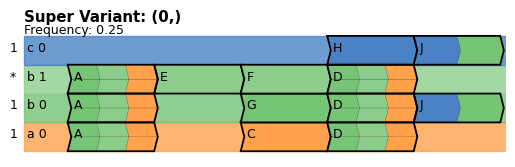

Super Variant Number:  0
Super Variant String:
 a 0: CAR 1: IP[0:0, A] CO[2:2, C] IP[3:3, D] b 0: CAR 1: IP[0:0, A] CO[2:2, G] IP[3:3, D] IP[4:4, J] b 1: CAR n: IP[0:0, A] CO[1:1, E] CO[2:2, F] IP[3:3, D] c 0: CAR 1: CO[3:3, H] IP[4:4, J] - IP[0,[a 0, b 0, b 1]] IP[0,[a 0, b 0, b 1]] IP[3,[a 0, b 0, b 1]] IP[3,[a 0, b 0, b 1]] IP[4,[b 0, c 0]] 


In [4]:
sample_variant = 0
first = all_summarizations[sample_variant]
SVV.visualize_super_variant(intra_variant_summarizations[sample_variant])

superVarNr = first[0]
superVarStr = first[1][0]
superVarRef = first[1][1]

print("Super Variant Number: ", superVarNr)
print("Super Variant String:\n", superVarStr)

@SuperLane.encode_lexicographically()

a 0 -> Lane a, instance 0

CAR 1 -> Lane instance is executed exactly once

Constructs: -> [startIndex:EndIndex]
- IP = Interaction Point
- CO = CommonConstruct / "Plain Activity"
- CH = ChoiceConstruct
- OP = OptionalConstruct

# Inter-Variant Summarization

Evaluating the decision of matching lane (3, 1) of Super Variant 1 with the lane (1,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
Evaluating the decision of matching lane (3, 1) of Super Variant 1 with the lane (3, 2) of Super Variant 2.
Not propagating.
------------------------------------
Evaluating the decision of matching lane (2,) of Super Variant 1 with the lane (3, 2) of Super Variant 2.
Propagating.
Propagating the last decision among [<Super_Variant_Definition.SuperLane object at 0x11e1b0890>] and [<Super_Variant_Definition.SuperLane object at 0x11e24bf50>].
Evaluating the decision of matching lane (0,) of Super Variant 1 with the lane (0,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Propagating.
Propagating the last decision among [] and [].
Empty. The rest is optional.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision

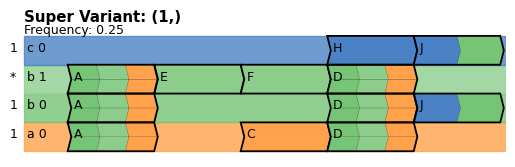

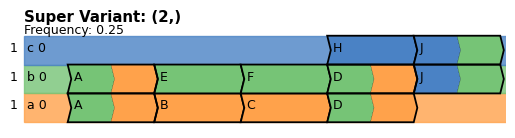

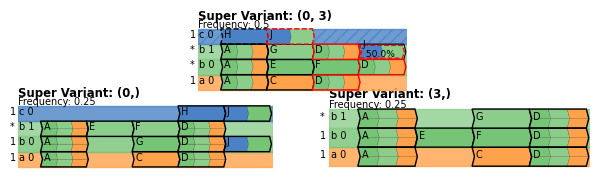

In [6]:
# MODE 1 - Frequency Distribution and No Nested Structures
IEVG.NESTED_STRUCTURES = False
initial_super_variants = intra_variant_summarizations

# Generating 3 hierarchies from the initial super variants with uniform frequency distribution
hierarchies, final_super_variants = IEVG.generate_super_variant_hierarchy(
    initial_super_variant_set=initial_super_variants,
    number_of_super_variants=4,
    base=3,
    frequency_distribution_type=IEVG.Distribution.UNIFORM
)

print("Hierarchies", hierarchies, "\n\n\n")
print("Final super variants", final_super_variants, "\n\n\n")

# Visualizing each hierarchy top-down
for final_super_variant in final_super_variants[0]:
    SVH.explore_hierarchy_top_down(final_super_variant)

# print_hierarchy_costs(hierarchies)

[{0: ([(<Super_Variant_Definition.SuperVariant object at 0x11c43edd0>, None, None)], 0)}, {0: ([(<Super_Variant_Definition.SuperVariant object at 0x11c488f90>, None, None)], 0)}, {1: ([(<Super_Variant_Definition.SuperVariant object at 0x13805c5d0>, (<Super_Variant_Definition.SuperVariant object at 0x11e100cd0>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x11e101e50>, None, None))], 3), 0: ([(<Super_Variant_Definition.SuperVariant object at 0x11c43fd10>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x11c427c50>, None, None)], 0)}] [0]


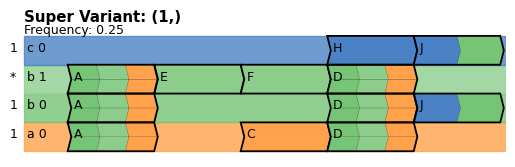

In [7]:
print(hierarchies[0], str([0]))
SVH.explore_hierarchy_top_down(final_super_variants[0][0])

In [8]:
print(hierarchies[0][0])

{0: ([(<Super_Variant_Definition.SuperVariant object at 0x11c43edd0>, None, None)], 0)}
